# Task 1: Problem Identification

Problem Type: Image Classification

Why?

* Each image belongs to exactly one category.

* The dataset uses labeled folders and a CSV file to match images with their classes.

* The model's goal is simply to predict the correct label for a whole image.

What it is NOT:

* Object Detection: No bounding boxes around objects.

* Segmentation (Semantic/Instance): No pixel-by-pixel outlines or masks.

Conclusion: This is a straightforward Image Classification task.

                                            filename   class
0  part_2_cnn_computer_vision/images/normal/norma...  normal
1  part_2_cnn_computer_vision/images/normal/norma...  normal
2  part_2_cnn_computer_vision/images/normal/norma...  normal
3  part_2_cnn_computer_vision/images/normal/norma...  normal
4  part_2_cnn_computer_vision/images/normal/norma...  normal
Classes: ['normal' 'scratch' 'dent' 'stain']
Number of Classes: 4
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


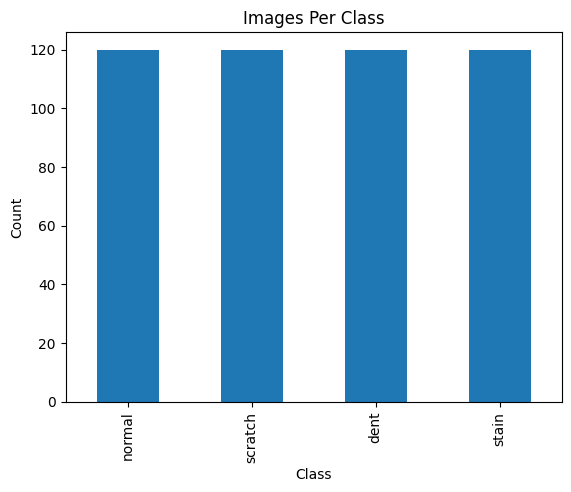

Opening: part_2_cnn_computer_vision/images/normal/normal_001.png


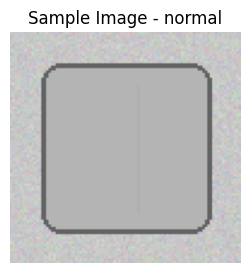

Opening: part_2_cnn_computer_vision/images/scratch/scratch_001.png


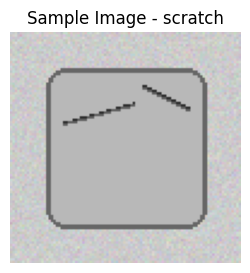

Opening: part_2_cnn_computer_vision/images/dent/dent_001.png


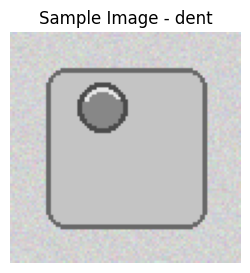

Opening: part_2_cnn_computer_vision/images/stain/stain_001.png


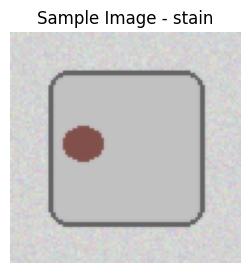

Image Size: (96, 96)


In [9]:
# Task 2 : Dataset Exploration

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load dataset
labels_df = pd.read_csv('part_2_cnn_computer_vision/labels.csv')

# Fix image paths
labels_df['filename'] = "part_2_cnn_computer_vision/" + labels_df['filename']

# Display first rows
print(labels_df.head())

# Number of classes
classes = labels_df['class'].unique()

print("Classes:", classes)
print("Number of Classes:", len(classes))

# Images per class
class_counts = labels_df['class'].value_counts()

print(class_counts)

# Plot class distribution
class_counts.plot(kind='bar')

plt.title('Images Per Class')
plt.xlabel('Class')
plt.ylabel('Count')

plt.show()

# Show sample images from each class
for cls in classes:

    sample_path = labels_df[labels_df['class'] == cls]['filename'].iloc[0]

    print("Opening:", sample_path)

    img = Image.open(sample_path)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"Sample Image - {cls}")
    plt.axis('off')
    plt.show()

# Image dimensions
sample_img = Image.open(labels_df['filename'].iloc[0])

print("Image Size:", sample_img.size)

Observations -

1. The dataset contains multiple image classes.
2. Images are grouped according to labels.
3. Some classes may contain more images than others, creating class imbalance.
4. Images may have different dimensions, so resizing is required before training.

# Task 3 : Image Preprocessing

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Constants
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Split dataset
train_df, test_df = train_test_split(
    labels_df,
    test_size=0.2,
    random_state=42,
    stratify=labels_df['class']
)

# Data augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Only normalization for testing
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation generator
validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Test generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 308 validated image filenames belonging to 4 classes.
Found 76 validated image filenames belonging to 4 classes.
Found 96 validated image filenames belonging to 4 classes.


# Task 4: CNN Model Creation

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

num_classes = len(classes)

model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

/Users/sakrak/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5: Model Training and Evaluation

In [12]:
# Training Code

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10


/Users/sakrak/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.2008 - loss: 1.5837 - val_accuracy: 0.2105 - val_loss: 1.4126
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.3069 - loss: 1.3895 - val_accuracy: 0.2632 - val_loss: 1.3830
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.2686 - loss: 1.3851 - val_accuracy: 0.2105 - val_loss: 1.3864
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.2574 - loss: 1.3850 - val_accuracy: 0.3421 - val_loss: 1.3890
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.3020 - loss: 1.3825 - val_accuracy: 0.2105 - val_loss: 1.3808
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.2888 - loss: 1.3709 - val_accuracy: 0.2237 - val_loss: 1.3696
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.2572 - loss: 1.3564 - val_accuracy: 0.3553 - val_loss: 1.3352
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.3469 - loss: 1.3220 - val_accuracy: 0.5132 - val_loss: 1.

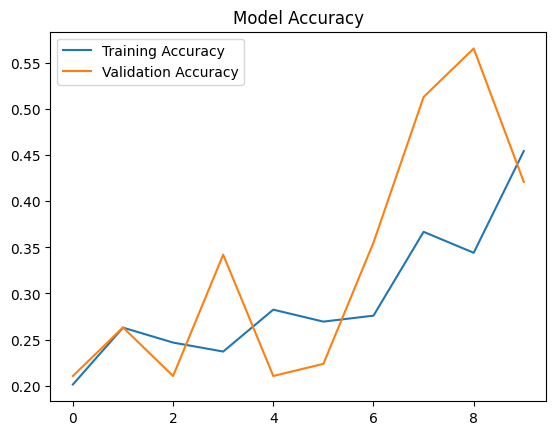

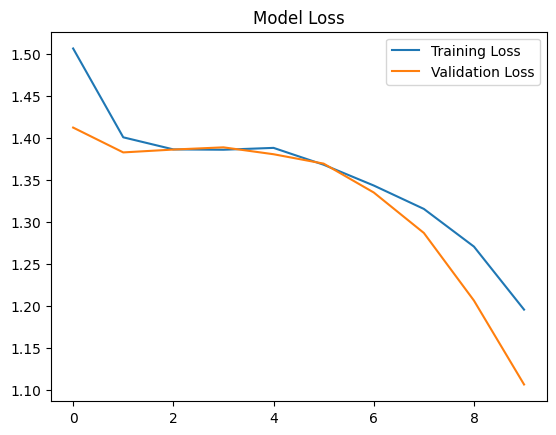

In [13]:
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [15]:
# Testing performance

test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5326 - loss: 0.9674
Test Loss: 0.9542465806007385
Test Accuracy: 0.5416666865348816


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


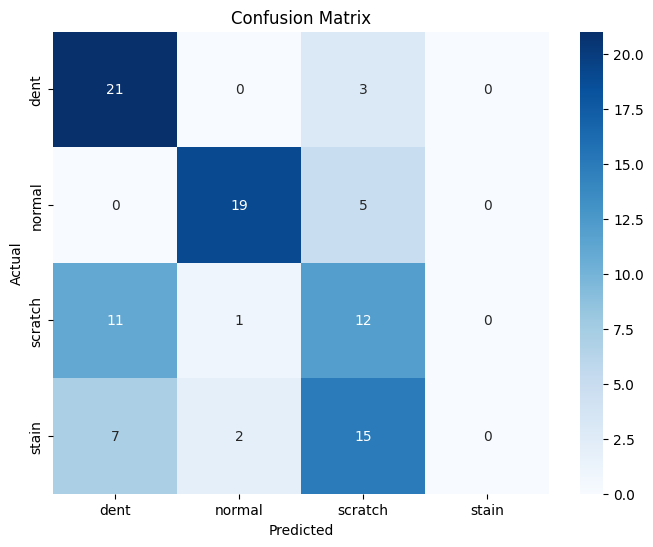

In [16]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Predictions
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


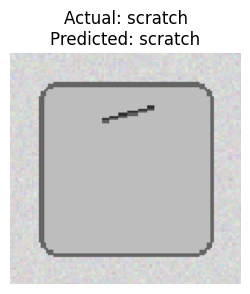

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


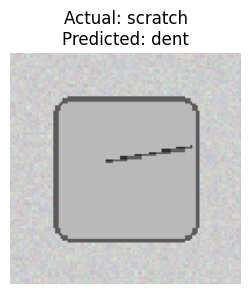

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


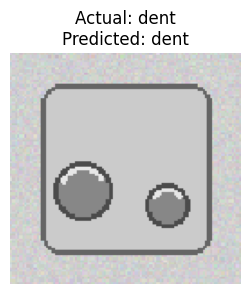

In [20]:
# Sample Predictions

num_samples = min(5, len(test_generator))

for i in range(num_samples):

    image, label = test_generator[i]

    prediction = model.predict(image)

    predicted_label = class_labels[np.argmax(prediction[0])]

    actual_label = class_labels[np.argmax(label[0])]

    plt.figure(figsize=(3,3))

    plt.imshow(image[0])

    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")

    plt.axis('off')

    plt.show()

# Task 6: CNN Concept Explanation

1. What is Convolution?
It is a process where small filters slide across an image to find key features like edges, shapes, and textures.

2. Why Use Pooling?
It shrinks the image size to speed up calculations and prevent the model from memorizing the data too perfectly (overfitting), while keeping the important details.

3. Why Use ReLU?
It introduces "non-linearity," which allows the network to learn complex, realistic patterns instead of just straight lines, while making training faster.

4. Why are CNNs Better for Images Than Regular Networks?
Regular networks flatten images and lose track of how pixels connect. CNNs are built specifically for images because they:

* Automatically find visual features.

* Keep track of where things are in the picture (spatial relationships).

* Use fewer parameters, making them much more efficient.

# Task 7: Business Use Case Mapping

Healthcare Use Case
_____________________

This image classification solution can be used in healthcare for medical image analysis.

Example:

A CNN model can classify X-ray or MRI images as:

* Normal
* Diseased
* Abnormal

Benefits:
* Faster diagnosis
* Reduced workload for doctors
* Early disease detection
* Improved healthcare accuracy

CNN-based systems are widely used in detecting:

* Pneumonia
* Brain tumors
* Skin cancer
* Diabetic retinopathy